In [1]:
# Get to know the data.

In [2]:
# Import all necessary libraries.
### All comments with three number signs are just for the grader to understand my thought process and will not be what I post to my GitHub.  After it's been graded and I know it's good enough for my portfolio I will delete these comments.
### I attempted to import all of the libaries from this class so that if I wanted to look at something during the preprocessing stage anything would be available. 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, BayesianRidge
from sklearn.preprocessing import MinMaxScaler
import os
from sklearn import preprocessing
from sklearn.metrics import pairwise
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from mord import LogisticIT
from dmba import classificationSummary, gainsChart, liftChart
from dmba.metric import AIC_score
from dmba import regressionSummary
from sklearn.model_selection import KFold, cross_val_score

In [3]:
# I choose to work with the bike dataset in days instead of hours to look at overall demand.
bike_df = pd.read_csv("day.csv")

In [4]:
# Look at the dataset.
bike_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [5]:
# Get a better understanding of hte dimensions. 
print(bike_df)

     instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0          1  2011-01-01       1   0     1        0        6           0   
1          2  2011-01-02       1   0     1        0        0           0   
2          3  2011-01-03       1   0     1        0        1           1   
3          4  2011-01-04       1   0     1        0        2           1   
4          5  2011-01-05       1   0     1        0        3           1   
..       ...         ...     ...  ..   ...      ...      ...         ...   
726      727  2012-12-27       1   1    12        0        4           1   
727      728  2012-12-28       1   1    12        0        5           1   
728      729  2012-12-29       1   1    12        0        6           0   
729      730  2012-12-30       1   1    12        0        0           0   
730      731  2012-12-31       1   1    12        0        1           1   

     weathersit      temp     atemp       hum  windspeed  casual  registered  \
0      

In [6]:
# Start preprocessing the data.

In [7]:
# Getting a list of columns all together can help make decisions. 
bike_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [8]:
# Check to see if you have any missing values.
nan_check_bike_df = bike_df.isna()
print(nan_check_bike_df)

     instant  dteday  season     yr   mnth  holiday  weekday  workingday  \
0      False   False   False  False  False    False    False       False   
1      False   False   False  False  False    False    False       False   
2      False   False   False  False  False    False    False       False   
3      False   False   False  False  False    False    False       False   
4      False   False   False  False  False    False    False       False   
..       ...     ...     ...    ...    ...      ...      ...         ...   
726    False   False   False  False  False    False    False       False   
727    False   False   False  False  False    False    False       False   
728    False   False   False  False  False    False    False       False   
729    False   False   False  False  False    False    False       False   
730    False   False   False  False  False    False    False       False   

     weathersit   temp  atemp    hum  windspeed  casual  registered    cnt  
0         

In [9]:
# Get a count of missing values.
has_nan = bike_df.isna().any().any()
print(f"Number of nan values: {has_nan}")

Number of nan values: False


In [10]:
# Look at the columns one more time so you can begin your preprocessing.
bike_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [11]:
# Make sure each columns' variables are the right kind that we can work with.
bike_df["season"] = bike_df["season"].astype("category")
bike_df["mnth"] = bike_df["mnth"].astype("category")
bike_df["holiday"] = bike_df["holiday"].astype("category")
bike_df["weekday"] = bike_df["weekday"].astype("category")
bike_df["weathersit"] = bike_df["weathersit"].astype("category")
bike_df["temp"] = bike_df["temp"].astype("float")
bike_df["atemp"] = bike_df["atemp"].astype("float")
bike_df["hum"] = bike_df["hum"].astype("float")
bike_df["windspeed"] = bike_df["windspeed"].astype("float")
bike_df["cnt"] = bike_df["cnt"].astype("int")

In [12]:
# Drop unneccessary columns. We want to know total count to be able to predict demand so we don't need categories, just total count.
bike_df = bike_df.drop(["casual", "registered", "instant"], axis = 1)

In [13]:
# Check on the changes you made.
bike_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [14]:
# Use MinMax scaler to scale numerical variables.
scaler = MinMaxScaler()
columns_to_scale = ["temp", "atemp", "hum", "windspeed", "cnt"]
bike_norm_df = pd.DataFrame(
    scaler.fit_transform(bike_df[columns_to_scale]),
    index=bike_df.index,
    columns=columns_to_scale
)

In [15]:
# Make sure it worked.
bike_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [16]:
# Now we want to standardize the numerical values so that we can also make calculations with categorical varaibles.
scaler = StandardScaler()
bike_df_norm = pd.DataFrame(scaler.fit_transform(bike_df[columns_to_scale]))

In [17]:
# Look at the results.
bike_df_norm.head()

,0,1,2,3,4
0,-0.826662,-0.679946,1.250171,-0.387892,-1.817953
1,-0.721095,-0.740652,0.479113,0.749602,-1.912999
2,-1.634657,-1.749767,-1.339274,0.746632,-1.629925
3,-1.614780,-1.610270,-0.263182,-0.389829,-1.519898
4,-1.467414,-1.504971,-1.341494,-0.046307,-1.500269


In [18]:
# Join the scaled data to the orginal DataFrame.
bike_df = bike_df.join(bike_df_norm)

In [19]:
# Check on the results
bike_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,0,1,2,3,4
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985,-0.826662,-0.679946,1.250171,-0.387892,-1.817953
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801,-0.721095,-0.740652,0.479113,0.749602,-1.912999
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349,-1.634657,-1.749767,-1.339274,0.746632,-1.629925
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562,-1.614780,-1.610270,-0.263182,-0.389829,-1.519898
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600,-1.467414,-1.504971,-1.341494,-0.046307,-1.500269


In [20]:
# Drop the unscaled columns.
bike_df = bike_df.drop(["temp", "atemp", "hum", "windspeed", "cnt"], axis = 1)

In [21]:
# Check the results.
bike_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,0,1,2,3,4
0,2011-01-01,1,0,1,0,6,0,2,-0.826662,-0.679946,1.250171,-0.387892,-1.817953
1,2011-01-02,1,0,1,0,0,0,2,-0.721095,-0.740652,0.479113,0.749602,-1.912999
2,2011-01-03,1,0,1,0,1,1,1,-1.634657,-1.749767,-1.339274,0.746632,-1.629925
3,2011-01-04,1,0,1,0,2,1,1,-1.614780,-1.610270,-0.263182,-0.389829,-1.519898
4,2011-01-05,1,0,1,0,3,1,1,-1.467414,-1.504971,-1.341494,-0.046307,-1.500269


In [22]:
# Rename the scaled columns to original names so it's easy to understand calculations.
bike_df = bike_df.rename(columns = {0 : "temp", 1 : "atemp", 2 : "hum", 3: "windspeed", 4 : "cnt"})

In [23]:
# Check results.
bike_df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,6,0,2,-0.826662,-0.679946,1.250171,-0.387892,-1.817953
1,2011-01-02,1,0,1,0,0,0,2,-0.721095,-0.740652,0.479113,0.749602,-1.912999
2,2011-01-03,1,0,1,0,1,1,1,-1.634657,-1.749767,-1.339274,0.746632,-1.629925
3,2011-01-04,1,0,1,0,2,1,1,-1.614780,-1.610270,-0.263182,-0.389829,-1.519898
4,2011-01-05,1,0,1,0,3,1,1,-1.467414,-1.504971,-1.341494,-0.046307,-1.500269


In [24]:
# Take another look to get a better grasp of your data.
bike_df.tail()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
726,2012-12-27,1,1,12,0,4,1,2,-1.318665,-1.521108,0.175807,2.061426,-1.234757
727,2012-12-28,1,1,12,0,5,1,2,-1.323224,-1.346690,-0.266238,-0.452131,-0.728012
728,2012-12-29,1,1,12,0,6,0,2,-1.323224,-1.424344,0.878392,-0.853552,-1.634057
729,2012-12-30,1,1,12,0,0,0,1,-1.309558,-1.490049,-1.015664,2.069444,-1.399023
730,2012-12-31,1,1,12,0,1,1,2,-1.528225,-1.540482,-0.354061,-0.460201,-0.917073


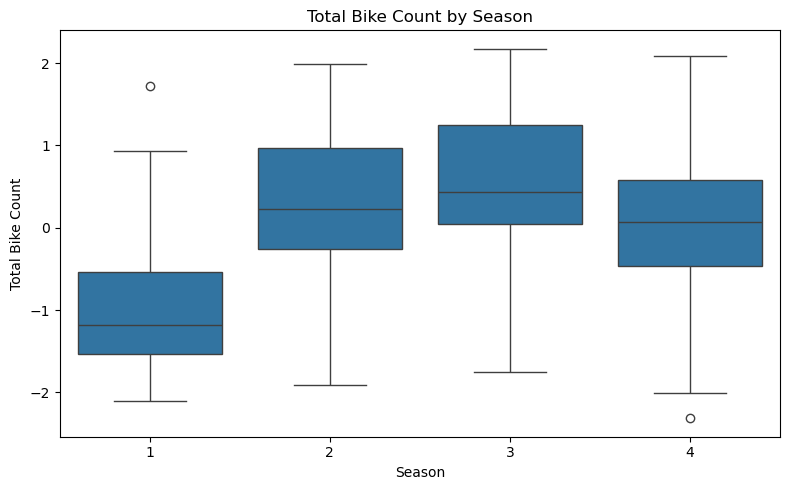

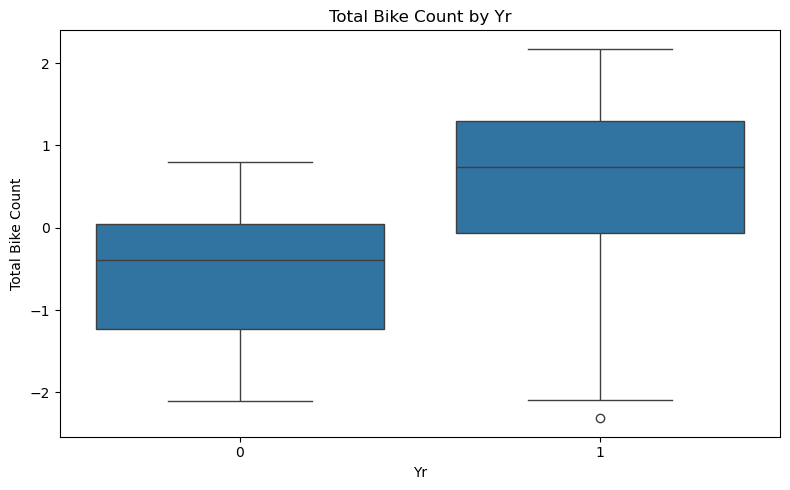

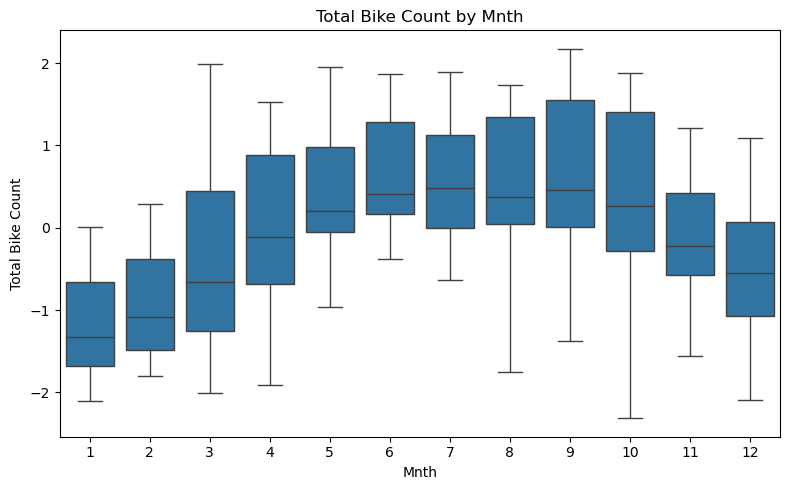

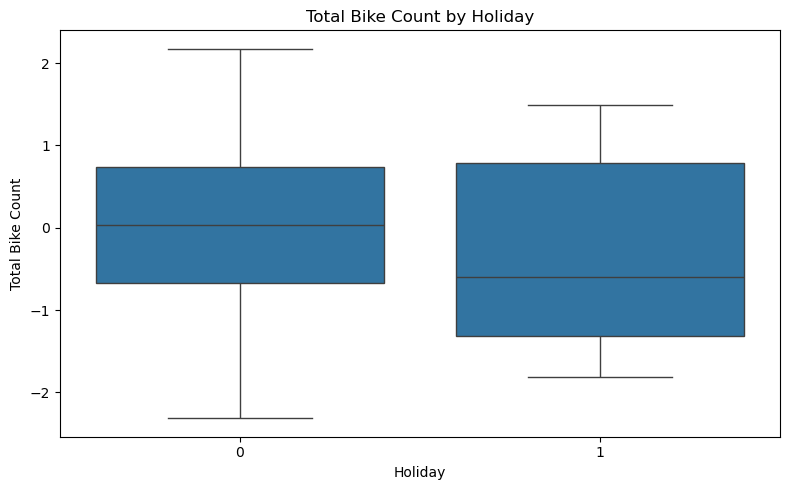

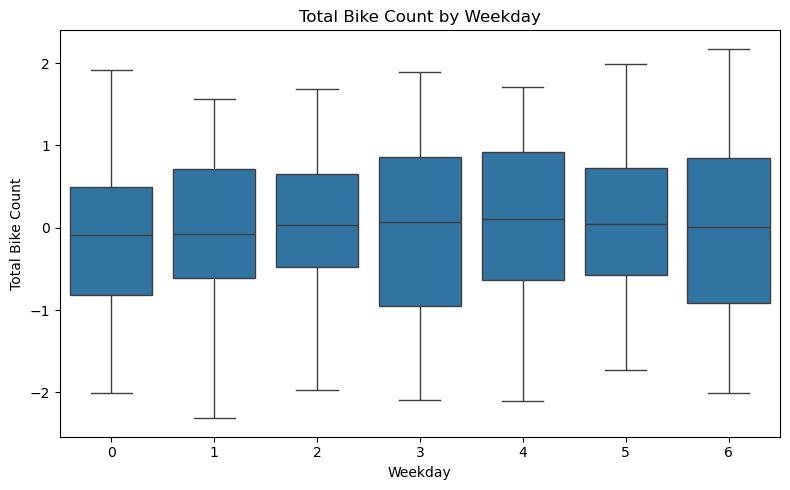

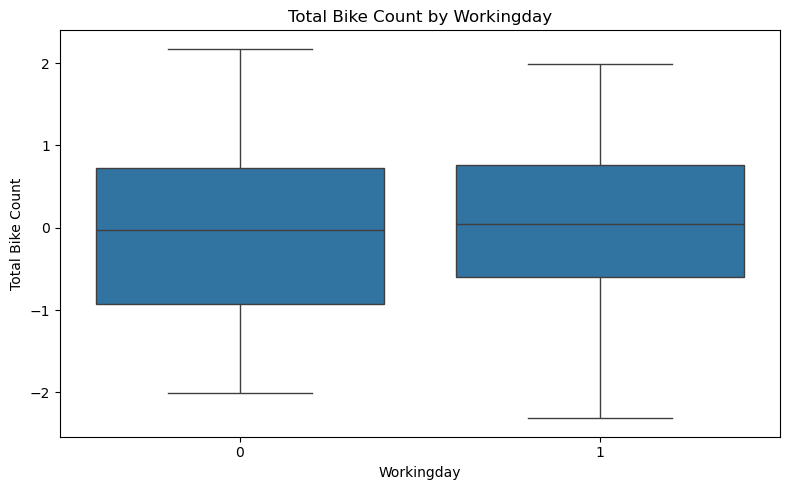

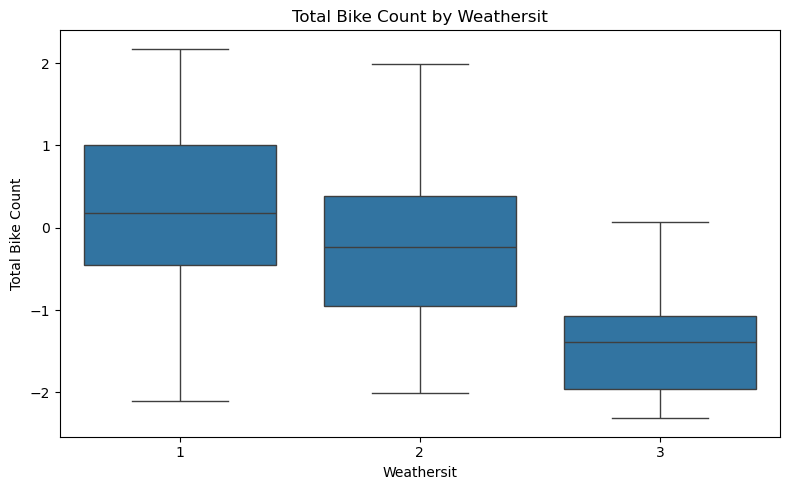

In [25]:
categorical_vars = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']

for var in categorical_vars:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=bike_df, x=var, y='cnt')
    plt.title(f'Total Bike Count by {var.capitalize()}')
    plt.xlabel(var.capitalize())
    plt.ylabel('Total Bike Count')
    plt.tight_layout()
    plt.show()

In [26]:
# Make a variable that holds all of your categorical data.
non_ordinal_cats = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]

In [27]:
# Now get all of the dummies at once.
dummies = pd.get_dummies(
    bike_df[non_ordinal_cats],
    prefix_sep="-",
    drop_first=True 
)

In [28]:
# Replace the categorical columns that haven't been processed with the new ones you got dummies for.
bike_df_encoded = pd.concat([
    bike_df.drop(columns=non_ordinal_cats),
    dummies
], axis=1)

In [29]:
# Make sure everything worked.
bike_df_encoded.head()

,dteday,temp,atemp,hum,windspeed,cnt,yr,workingday,season-2,season-3,...,mnth-12,holiday-1,weekday-1,weekday-2,weekday-3,weekday-4,weekday-5,weekday-6,weathersit-2,weathersit-3
0,2011-01-01,-0.826662,-0.679946,1.250171,-0.387892,-1.817953,0,0,False,False,...,False,False,False,False,False,False,False,True,True,False
1,2011-01-02,-0.721095,-0.740652,0.479113,0.749602,-1.912999,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2011-01-03,-1.634657,-1.749767,-1.339274,0.746632,-1.629925,0,1,False,False,...,False,False,True,False,False,False,False,False,False,False
3,2011-01-04,-1.614780,-1.610270,-0.263182,-0.389829,-1.519898,0,1,False,False,...,False,False,False,True,False,False,False,False,False,False
4,2011-01-05,-1.467414,-1.504971,-1.341494,-0.046307,-1.500269,0,1,False,False,...,False,False,False,False,True,False,False,False,False,False


In [30]:
# Change the name back to bike_df to make things easier for yourself.
bike_df = bike_df_encoded

In [31]:
# Make sure it worked.
bike_df.head()

,dteday,temp,atemp,hum,windspeed,cnt,yr,workingday,season-2,season-3,...,mnth-12,holiday-1,weekday-1,weekday-2,weekday-3,weekday-4,weekday-5,weekday-6,weathersit-2,weathersit-3
0,2011-01-01,-0.826662,-0.679946,1.250171,-0.387892,-1.817953,0,0,False,False,...,False,False,False,False,False,False,False,True,True,False
1,2011-01-02,-0.721095,-0.740652,0.479113,0.749602,-1.912999,0,0,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2011-01-03,-1.634657,-1.749767,-1.339274,0.746632,-1.629925,0,1,False,False,...,False,False,True,False,False,False,False,False,False,False
3,2011-01-04,-1.614780,-1.610270,-0.263182,-0.389829,-1.519898,0,1,False,False,...,False,False,False,True,False,False,False,False,False,False
4,2011-01-05,-1.467414,-1.504971,-1.341494,-0.046307,-1.500269,0,1,False,False,...,False,False,False,False,True,False,False,False,False,False


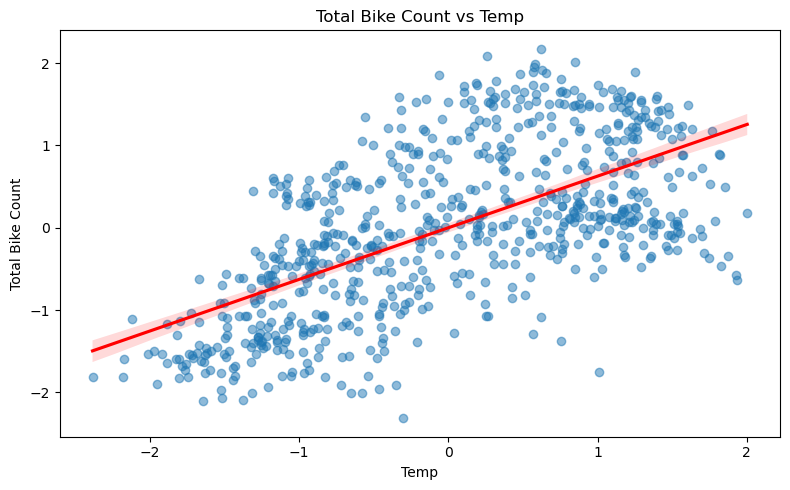

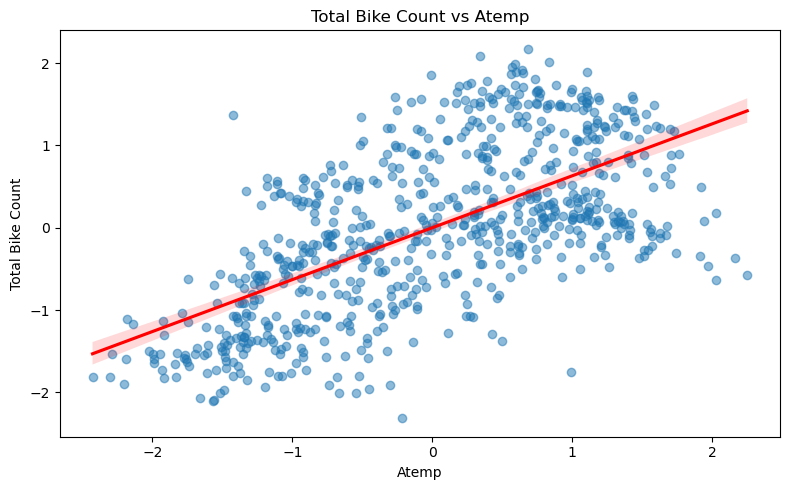

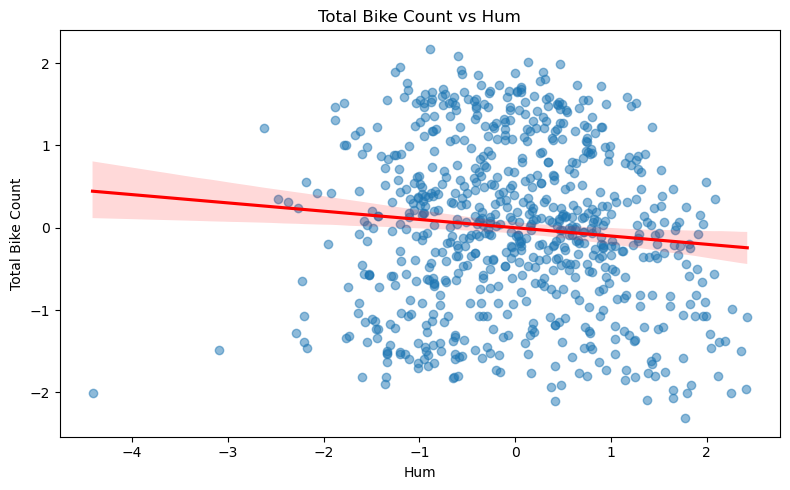

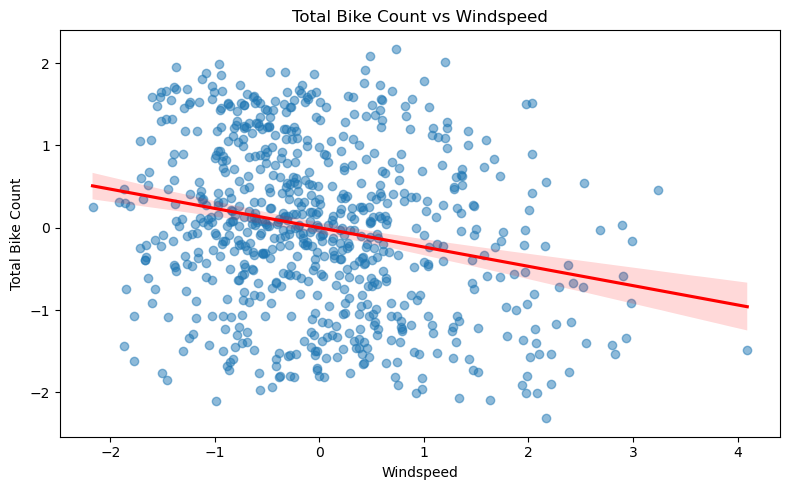

In [32]:
continuous_vars = ["temp", "atemp", "hum", "windspeed"]

for var in continuous_vars:
    plt.figure(figsize=(8, 5))
    sns.regplot(data = bike_df, x = var, y = "cnt", scatter_kws={"alpha" : 0.5}, line_kws={"color":"red"})
    plt.title(f"Total Bike Count vs {var.capitalize()}")
    plt.xlabel(var.capitalize())
    plt.ylabel('Total Bike Count')
    plt.tight_layout()
    plt.savefig(f'regression_{var}.png', bbox_inches='tight')
    plt.show()

In [33]:
# Multiple Linear Regression

In [34]:
# Partition the data.
predictors = ["temp", "hum", "windspeed", "workingday"]
outcome = "cnt"
X = bike_df[predictors]
y = bike_df[outcome]

In [35]:
 train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size = 0.4, random_state = 1)

In [36]:
# Run Linear Regression
bike_df = LinearRegression()
bike_df.fit(train_X, train_y)

LinearRegression()

In [37]:
# Look at the coefficients.
print(pd.DataFrame({"Predictor" : X.columns, "coefficient" : bike_df.coef_}))

    Predictor  coefficient
0        temp     0.586938
1         hum    -0.255275
2   windspeed    -0.185245
3  workingday     0.045824


In [38]:
# Look a the Regression statistics.
regressionSummary(train_y, bike_df.predict(train_X))


Regression statistics

                      Mean Error (ME) : 0.0000
       Root Mean Squared Error (RMSE) : 0.7560
            Mean Absolute Error (MAE) : 0.6252
          Mean Percentage Error (MPE) : 61.9570
Mean Absolute Percentage Error (MAPE) : 231.0998


In [39]:
# use predict() to make predictions on the validation set.
bike_df_pred = bike_df.predict(valid_X)
result = pd.DataFrame({"Predicted" : bike_df_pred, "Actual" : valid_y, "Residual" : valid_y - bike_df_pred})
print(result.head(20))

     Predicted    Actual  Residual
404  -0.597822 -0.348341  0.249481
726  -1.168869 -1.234757 -0.065888
159   1.239927 -0.304434 -1.544361
422  -0.320819 -0.094194  0.226625
512   0.427336  1.077879  0.650543
241   0.792510  0.361411 -0.431098
698  -0.347563  0.422882  0.770445
247   0.212382 -0.595773 -0.808155
355  -0.089229 -0.741959 -0.652731
528   0.112638  0.241570  0.128931
120  -0.193675 -0.595773 -0.402099
69   -0.682535 -1.305526 -0.622991
8    -1.222292 -1.902152 -0.679860
364  -0.337270 -1.043114 -0.705843
524   0.848329  1.669340  0.821011
368  -0.816300 -1.103551 -0.287251
180   1.037519  0.522061 -0.515458
495  -0.094245  1.068065  1.162309
259  -0.186164  0.003436  0.189600
506  -0.068858 -0.075081 -0.006223


In [40]:
# Print performance measures.
regressionSummary(valid_y, bike_df.predict(valid_X))


Regression statistics

                      Mean Error (ME) : -0.0433
       Root Mean Squared Error (RMSE) : 0.7042
            Mean Absolute Error (MAE) : 0.5740
          Mean Percentage Error (MPE) : -130.2499
Mean Absolute Percentage Error (MAPE) : 364.2263


In [41]:
# Check the shape of train_X and valid_X.
print("train_X shape:" , train_X.shape)
print("valid_X shape:" , valid_X.shape)

train_X shape: (438, 4)
valid_X shape: (293, 4)


In [42]:
# Run Lasso regression.
lasso = Lasso(alpha = 1)
lasso.fit(train_X, train_y)
regressionSummary(valid_y, lasso.predict(valid_X)) # I did not Standardize the data again because the results were exactly the same when I did.


Regression statistics

                      Mean Error (ME) : -0.1174
       Root Mean Squared Error (RMSE) : 1.0271
            Mean Absolute Error (MAE) : 0.8561
          Mean Percentage Error (MPE) : 76.4804
Mean Absolute Percentage Error (MAPE) : 123.5386


In [43]:
# Run Ridge Regression.
ridge = Ridge(alpha = 1)
ridge.fit(train_X, train_y)
regressionSummary(valid_y, ridge.predict(valid_X))


Regression statistics

                      Mean Error (ME) : -0.0435
       Root Mean Squared Error (RMSE) : 0.7044
            Mean Absolute Error (MAE) : 0.5743
          Mean Percentage Error (MPE) : -129.6866
Mean Absolute Percentage Error (MAPE) : 363.5149


In [44]:
# Run Bayesian Ridge Regression.
bayesianRidge = BayesianRidge()
bayesianRidge.fit(train_X, train_y)
regressionSummary(valid_y, bayesianRidge.predict(valid_X))


Regression statistics

                      Mean Error (ME) : -0.0440
       Root Mean Squared Error (RMSE) : 0.7051
            Mean Absolute Error (MAE) : 0.5758
          Mean Percentage Error (MPE) : -127.3606
Mean Absolute Percentage Error (MAPE) : 360.5750


In [45]:
# Create the model - Lasso.
lasso_model = Lasso(alpha = 1.0)

In [46]:
# Define the k-fold cross validator.
k = 5
kf = KFold(n_splits = k, shuffle = True, random_state = 42)

In [47]:
# Perform k-fold cross-validation.
lasso_scores = cross_val_score(lasso_model, X, y, cv = kf, scoring = "neg_mean_squared_error")

In [48]:
# Convert the scores to positive values and take the square root to get RMSE.
lasso_rmse_scores = np.sqrt(-lasso_scores)

In [49]:
# Print the results.
print(f"Lasso RMSE scores for each fold : {lasso_rmse_scores}")
print(f"Average Lasso RMSE : {lasso_rmse_scores.mean()}")
print(f"Standard Deviation of Lasso RMSE : {lasso_rmse_scores.std()}")

Lasso RMSE scores for each fold : [1.04457228 0.98608254 1.01116391 0.94778411 1.02499212]
Average Lasso RMSE : 1.002918990997695
Standard Deviation of Lasso RMSE : 0.0335067743813787


In [50]:
# Create the model - Ridge
ridge_model = Ridge(alpha = 1.0)

In [51]:
#Define the k-fold cross-validator.
k = 5
kf = KFold(n_splits = k, shuffle = True, random_state = 42)

In [52]:
# Perform k-fold cross-validation.
ridge_scores = cross_val_score(ridge_model, X, y, cv = kf, scoring = "neg_mean_squared_error")

In [53]:
# Convert the scores to positive values and tkae the square root to get RMSE.
ridge_rmse_scores = np.sqrt(-ridge_scores)

In [54]:
# Print the results.
print(f"Ridge RMSE scores for each fold: {ridge_rmse_scores}")
print(f"Average Ridge RMSE: {ridge_rmse_scores.mean()}")
print(f"Standard Deviation of Ridge RMSE: {ridge_rmse_scores.std()}")

Ridge RMSE scores for each fold: [0.7332558  0.78246369 0.70958069 0.73473321 0.73811731]
Average Ridge RMSE: 0.7396301392302057
Standard Deviation of Ridge RMSE: 0.023683676579988974


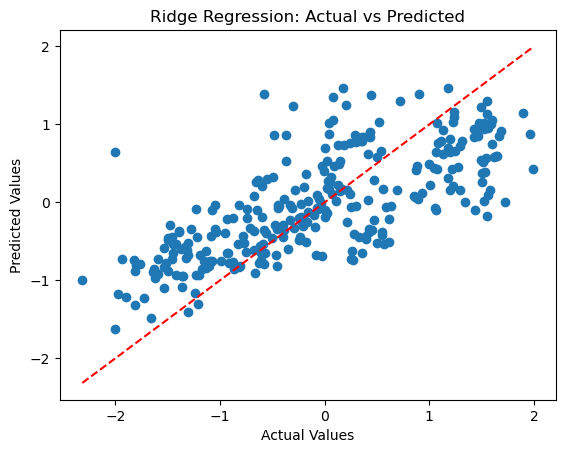

In [55]:
# Make a scatter plot to visualize the Ridge Regression since it was the most accurate.
y_pred = ridge.predict(valid_X)

plt.scatter(valid_y, y_pred, alpha=1.0)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")

# Reference line: perfect prediction
min_val = min(valid_y.min(), y_pred.min())
max_val = max(valid_y.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.savefig("ridge_actual_vs_predicted.png", bbox_inches="tight")
plt.show()

In [56]:
# Time Series Analysis

In [57]:
# Reload the dataset to ensure bike_df is a DataFrame.
bike_df = pd.read_csv("day.csv")

# Convert "dteday" to datetime format.
bike_df["dteday"] = pd.to_datetime(bike_df["dteday"])

# Set "dteday" as the index.
bike_df.set_index("dteday", inplace=True)

# Set frequency for time series analysis.
bike_df = bike_df.asfreq("D")

# Parse the target variable as a time series.
bike_series = bike_df["cnt"]

In [58]:
# Define a finction to calculate error metrics.
def calculate_metrics(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return mape, mae, mse, rmse

In [59]:
# Extend the index to include the next 365 days.
future_dates = pd.date_range(start=bike_series.index[-1] + pd.offsets.Day(), periods=365, freq="D")

In [60]:
# 7-Day Moving Average
### I chose 7 because they are 7 days in a week which would show us the fluctuations by week.
moving_avg_7 = bike_series.rolling(window = 7).mean()

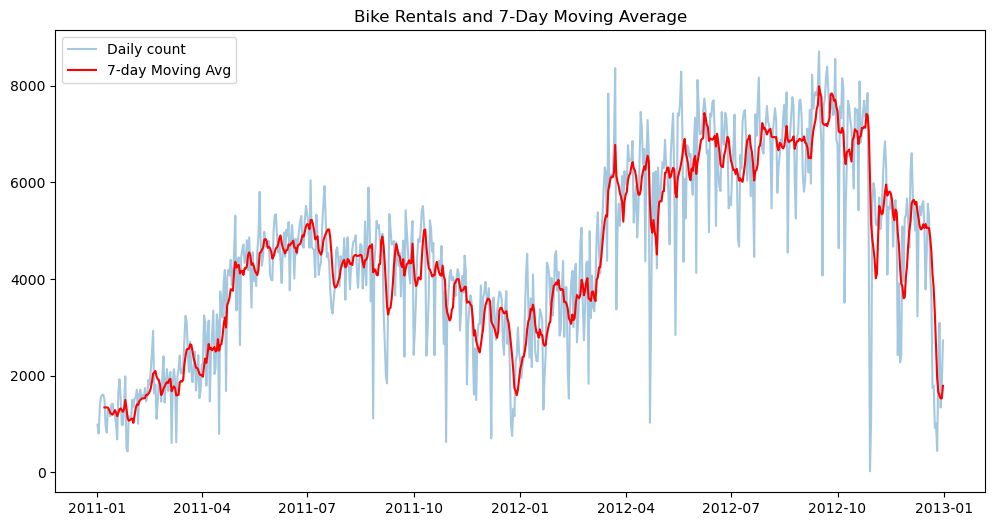

In [61]:
# Look that results visually by plotting.
plt.figure(figsize=(12, 6))
plt.plot(bike_series, label="Daily count", alpha=0.4)
plt.plot(moving_avg_7, label="7-day Moving Avg", color="red")
plt.legend()
plt.title("Bike Rentals and 7-Day Moving Average")
plt.savefig("bike_rentals_moving_avg.png", bbox_inches="tight")
plt.show()

In [62]:
# Make predictions for the next 7 days.
moving_avg_7_future = []
extended_series = bike_series.copy()
for _ in range(7):
    next_value = extended_series[-7:].mean()
    moving_avg_7_future.append(next_value)
    extended_series = pd.concat([extended_series, pd.Series([next_value], index = [extended_series.index[-1] + pd.offsets.Day()])])

In [63]:
# Print the results
for i, prediction in enumerate(moving_avg_7_future, 1):
    print(f"Day {i} prediction {prediction: .2f}")

Day 1 prediction  1789.86
Day 2 prediction  1900.84
Day 3 prediction  2109.38
Day 4 prediction  2108.73
Day 5 prediction  1967.83
Day 6 prediction  2057.38
Day 7 prediction  2094.72


In [64]:
# 30-Day Moving Average
### I chose 30 because they are typically 30 days in a month which would roughly show us the fluctuations by year.
moving_avg_30 = bike_series.rolling(window = 30).mean()

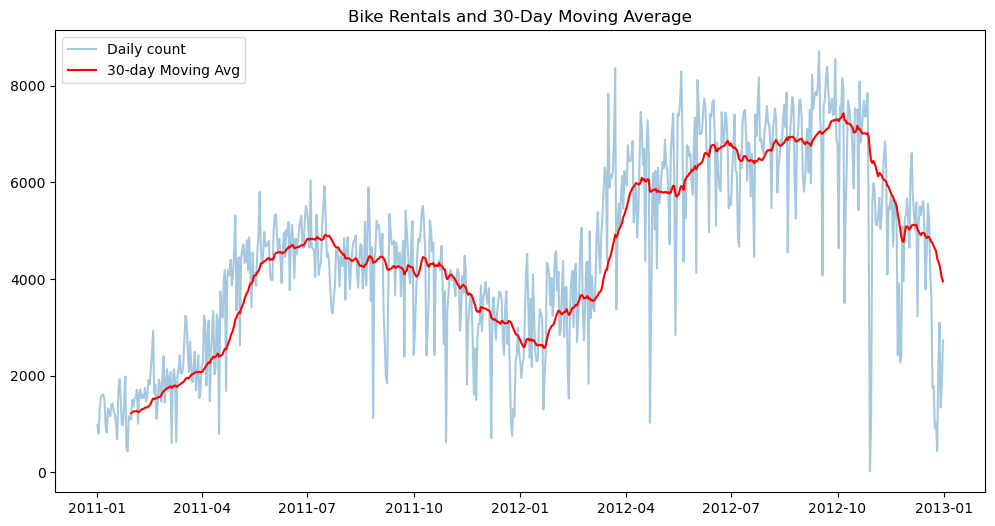

In [65]:
# Look the results visually.
plt.figure(figsize=(12, 6))
plt.plot(bike_series, label="Daily count", alpha=0.4)
plt.plot(moving_avg_30, label="30-day Moving Avg", color="red")
plt.legend()
plt.title("Bike Rentals and 30-Day Moving Average")
plt.show()

In [66]:
# Make predictions for the next 30 days.
moving_avg_30_future = []
extended_series = bike_series.copy()
for _ in range(7):
    next_value = extended_series[-30:].mean()
    moving_avg_30_future.append(next_value)
    extended_series = pd.concat([extended_series, pd.Series([next_value], index = [extended_series.index[-1] + pd.offsets.Day()])])

In [67]:
# Print the results.
for i, prediction in enumerate(moving_avg_30_future, 1):
    print(f"Day {i} prediction {prediction: .2f}")

Day 1 prediction  3950.73
Day 2 prediction  3927.46
Day 3 prediction  3850.57
Day 4 prediction  3758.73
Day 5 prediction  3693.05
Day 6 prediction  3636.98
Day 7 prediction  3591.28


In [68]:
# Weighted 7 Day Moving Average without Lambda Function.
weighted_moving_avg_7_future = []
extended_series = bike_series.copy() # It's a good idea to not change original dataset.

weights = np.array([0.5, 0.3, 0.2])
weights = weights / weights.sum()  # Normalize weights

for _ in range(7):
    if len(extended_series) < len(weights):
        next_value = extended_series.mean()  # this handles missing values just in case I missed them
    else:
        recent_values = extended_series[-len(weights):]
        next_value = np.dot(recent_values.values[::-1], weights) ### The original code that we learned in class was not working, so I did some research and found the dot function.  This grabs the most recent and reverses the order and performs a dot product calculation on them.  A dot product combines two vectors to produce a single scaler vector, essentially a differnt way of standardizing the values.
    
    weighted_moving_avg_7_future.append(next_value)
    next_index = extended_series.index[-1] + pd.offsets.Day()
    extended_series = pd.concat([extended_series, pd.Series([next_value], index=[next_index])])
### The code from the book was not working so I did some research and found these work arounds.

In [69]:
# Print the results.
for i, prediction in enumerate(weighted_moving_avg_7_future, 1):
    print(f"Day {i} weighted prediction : {prediction: .2f}")

Day 1 weighted prediction :  2171.50
Day 2 weighted prediction :  2263.65
Day 3 weighted prediction :  2329.07
Day 4 weighted prediction :  2277.93
Day 5 weighted prediction :  2290.42
Day 6 weighted prediction :  2294.40
Day 7 weighted prediction :  2289.91


In [70]:
# Exponential Smoothing with smoothing constant 0.2 using Holt.
exp_smoothing_0_2_model = Holt(bike_series, initialization_method = "estimated").fit(smoothing_level = 0.2)
exp_smoothing_0_2 = exp_smoothing_0_2_model.fittedvalues
exp_smoothing_0_2_future = exp_smoothing_0_2_model.forecast(30)

In [71]:
# Print the results.
for i, prediction in enumerate(exp_smoothing_0_2_future, 1):
    print(f"Day {i} exponential smoothing preduction: {prediction : .2f}")

Day 1 exponential smoothing preduction:  2149.30
Day 2 exponential smoothing preduction:  2133.30
Day 3 exponential smoothing preduction:  2117.29
Day 4 exponential smoothing preduction:  2101.29
Day 5 exponential smoothing preduction:  2085.29
Day 6 exponential smoothing preduction:  2069.28
Day 7 exponential smoothing preduction:  2053.28
Day 8 exponential smoothing preduction:  2037.27
Day 9 exponential smoothing preduction:  2021.27
Day 10 exponential smoothing preduction:  2005.27
Day 11 exponential smoothing preduction:  1989.26
Day 12 exponential smoothing preduction:  1973.26
Day 13 exponential smoothing preduction:  1957.25
Day 14 exponential smoothing preduction:  1941.25
Day 15 exponential smoothing preduction:  1925.25
Day 16 exponential smoothing preduction:  1909.24
Day 17 exponential smoothing preduction:  1893.24
Day 18 exponential smoothing preduction:  1877.24
Day 19 exponential smoothing preduction:  1861.23
Day 20 exponential smoothing preduction:  1845.23
Day 21 ex

In [72]:
# Simple Linear Regression - just to see what other options we have.
days = np.arange(len(bike_series)).reshape(-1, 1)
reg_model = LinearRegression().fit(days, bike_series)
future_days = np.arange(len(bike_series), len(bike_series) + 6).reshape(-1, 1)
linear_regression = reg_model.predict(days)
linear_regression_future = reg_model.predict(future_days)
linear_regression_series = pd.Series(linear_regression, index=bike_series.index)

In [73]:
# Print the reuslts.
for i, prediction in enumerate(linear_regression_future, 1):
    print(f"Month {i} linear regression prediction: {prediction : .2f}")

Month 1 linear regression prediction:  6615.74
Month 2 linear regression prediction:  6621.51
Month 3 linear regression prediction:  6627.27
Month 4 linear regression prediction:  6633.04
Month 5 linear regression prediction:  6638.81
Month 6 linear regression prediction:  6644.58


In [74]:
### The original calculate_metrics function did not work, so I reset the indexes to match with the actual and was able to get the results.
def calculate_metrics(actual, forecast):
    common_index = actual.index.intersection(forecast.index)
    actual_aligned = actual.loc[common_index]
    forecast_aligned = forecast.loc[common_index]

    mae = mean_absolute_error(actual_aligned, forecast_aligned)
    mse = mean_squared_error(actual_aligned, forecast_aligned)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual_aligned - forecast_aligned) / actual_aligned)) * 100
    return mape, mae, mse, rmse
# Create a Series with the correct index for the last 7 days
forecast_series_7 = pd.Series(weighted_moving_avg_7_future, index=bike_series.index[-7:])

# Then use it in your metrics dictionary
metric = {
    "7-Day Moving Average": calculate_metrics(bike_series, moving_avg_7.dropna()),
    "30-Day Moving Average": calculate_metrics(bike_series, moving_avg_30.dropna()),
    "7-Day Weighted Moving Average": calculate_metrics(bike_series[-7:], forecast_series_7),
    "Exponential Smoothing 0.2": calculate_metrics(bike_series, exp_smoothing_0_2),
    "Linear Regression": calculate_metrics(bike_series, linear_regression_series)
}

In [75]:
# Put the results into a DataFrame and print them.
metrics_df = pd.DataFrame(metric, index = ["MAPE", "MAE", "MSE", "RMSE"])
metrics_df

,7-Day Moving Average,30-Day Moving Average,7-Day Weighted Moving Average,Exponential Smoothing 0.2,Linear Regression
MAPE,58.353356,6.740802e+01,96.982251,65.703146,8.287322e+01
MAE,625.580296,7.403320e+02,842.885884,682.427738,1.229867e+03
MSE,754703.192287,1.065746e+06,960090.116156,938431.489528,2.265729e+06
RMSE,868.736549,1.032350e+03,979.841883,968.726736,1.505234e+03
